# Hyperparameter Tuning — Federal Court Case LOS Prediction

This notebook systematically searches for the best hyperparameters for each model:
- **Random Forest** — `RandomizedSearchCV` over 4 parameters
- **XGBoost** — `RandomizedSearchCV` over 4 parameters
- **Neural Network** — manual grid (8 configs) with early stopping

Search is run on a 25 000-row sample for speed; the final "best" models are retrained on full data.

Outputs saved to:
- `reports/figures/05_*.png` — all visualizations
- `docs/05_hyperparameter_results.json` — best configs + metrics

## 0. Setup

In [ ]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

FIGS_DIR = ROOT / "reports" / "figures"
DOCS_DIR = ROOT / "docs"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(exist_ok=True)

SEARCH_SAMPLE = 25_000
CV_FOLDS      = 3
N_ITER        = 15
RANDOM_SEED   = 42

def _param_grouped(cv_df, col):
    """Group a RandomizedSearchCV results DataFrame by one param column.

    Casts the column to str to handle mixed types (None, float, str),
    then sorts numerically where possible and alphabetically otherwise.
    """
    tmp = cv_df[[col, "cv_mae"]].copy()
    tmp[col] = tmp[col].astype(str)
    grouped = tmp.groupby(col)["cv_mae"].agg(["mean", "std", "count"]).reset_index()
    grouped["_sort"] = pd.to_numeric(grouped[col], errors="coerce")
    grouped = (grouped
               .sort_values("_sort", na_position="last")
               .drop(columns="_sort")
               .reset_index(drop=True))
    return grouped

def _sort_str_labels(labels):
    """Sort string labels numerically first, non-numeric last."""
    def _key(s):
        try:    return (0, float(s))
        except: return (1, s)
    return sorted(labels, key=_key)

print(f"ROOT: {ROOT}")
print(f"Search sample: {SEARCH_SAMPLE:,}  |  CV folds: {CV_FOLDS}  |  Iterations: {N_ITER}")

ROOT: /Users/mariamantsurova/Desktop/University/3rd Year/federal-court-complexity
Search sample: 25,000  |  CV folds: 3  |  Iterations: 15


## 1. Load & Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.preprocessing_trees import prepare_for_trees

df = pd.read_parquet(ROOT / "data" / "aggregations" / "by_case.parquet")
print(f"Loaded {len(df):,} cases")

# Temporal split: train on cases filed before the 80th-percentile open date,
# test on cases filed after — mirrors real deployment (predict newly filed cases).
dates = pd.to_datetime(df["case_open_date"])
cutoff = dates.quantile(0.8)
cutoff_str = str(cutoff)[:10]
train_df = df[dates < cutoff].copy() # type: ignore
test_df  = df[dates >= cutoff].copy() # type: ignore
print(f"Temporal cutoff: {cutoff_str}  |  Train: {len(train_df):,}  Test: {len(test_df):,}")

X_train_full, y_train_full = prepare_for_trees(train_df)
X_test,        y_test       = prepare_for_trees(test_df)
# Suit feature columns are dynamic (one column per suit type seen in each split).
# Align test to training columns: fill unseen suits with 0, drop new test-only suits.
X_test = X_test.reindex(columns=X_train_full.columns, fill_value=0)
print(f"Feature matrix: {X_train_full.shape[1]} features")

# Subsample training data for faster CV search
rng = np.random.RandomState(RANDOM_SEED)
sample_idx = rng.choice(len(X_train_full), SEARCH_SAMPLE, replace=False)
X_sample = X_train_full.iloc[sample_idx]
y_sample = y_train_full.iloc[sample_idx]
print(f"CV search sample: {len(X_sample):,} rows")

Loaded 168,107 cases
Temporal cutoff: 2015-09-11  |  Train: 134,466  Test: 33,641
Feature matrix: 241 features
CV search sample: 25,000 rows


## 2. Random Forest Hyperparameter Search

### 2.1 Randomized Search (CV)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    "n_estimators":    [100, 200, 300, 500],
    "max_depth":       [8, 12, 15, 20, None],
    "min_samples_leaf":[2, 5, 10, 20],
    "max_features":    ["sqrt", "log2", 0.4, 0.6],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_SEED,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

print("Running RandomizedSearchCV for Random Forest ...")
t0 = time.time()
rf_search.fit(X_sample, y_sample)
print(f"Done in {time.time() - t0:.1f}s")

rf_cv = pd.DataFrame(rf_search.cv_results_)
rf_cv["cv_mae"]  = -rf_cv["mean_test_score"]
rf_cv["cv_mae_std"] = rf_cv["std_test_score"]
rf_cv = rf_cv.sort_values("cv_mae").reset_index(drop=True)

display_cols = [
    "param_n_estimators", "param_max_depth", "param_min_samples_leaf",
    "param_max_features", "cv_mae", "cv_mae_std"
]
print("\nTop 10 RF configurations (by CV MAE):")
rf_cv[display_cols].head(10).style.format({"cv_mae": "{:.1f}", "cv_mae_std": "{:.1f}"})

Running RandomizedSearchCV for Random Forest ...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Done in 90.3s

Top 10 RF configurations (by CV MAE):


,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,cv_mae,cv_mae_std
0,300,20,5,0.400000,246.3,1.6
1,500,15,5,0.400000,247.0,1.5
2,100,20,5,0.600000,247.3,1.5
3,100,20,2,0.400000,247.6,1.3
4,300,15,10,0.600000,248.3,1.6
5,100,20,2,0.600000,248.8,1.8
6,100,15,20,0.400000,252.3,1.8
7,300,12,20,0.400000,253.3,1.4
8,500,8,20,0.600000,257.2,1.6
9,500,15,20,sqrt,274.0,1.6


### 2.2 Visualizations

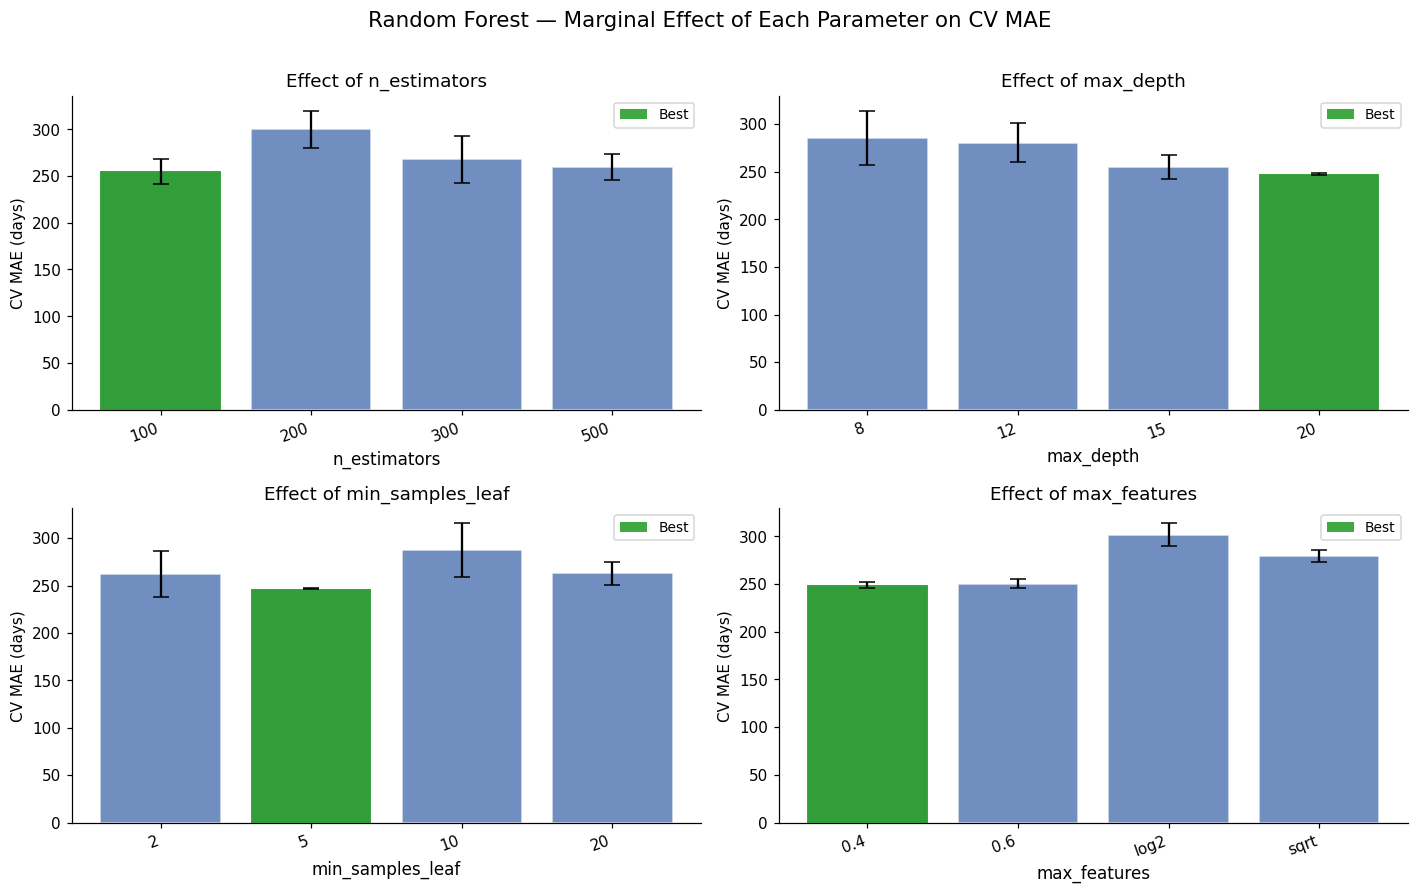

Saved 05_rf_param_sensitivity.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Random Forest — Marginal Effect of Each Parameter on CV MAE", fontsize=14, y=1.01)

param_cols = [
    ("param_n_estimators",    "n_estimators"),
    ("param_max_depth",       "max_depth"),
    ("param_min_samples_leaf","min_samples_leaf"),
    ("param_max_features",    "max_features"),
]

for ax, (col, label) in zip(axes.flat, param_cols):
    grouped = _param_grouped(rf_cv, col)
    x_pos   = np.arange(len(grouped))

    ax.bar(x_pos, grouped["mean"],
           yerr=grouped["std"].fillna(0),      # fillna: std is NaN when a group has 1 sample
           capsize=5, color="#4C72B0", alpha=0.8, edgecolor="white")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(grouped[col].tolist(), rotation=20, ha="right")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("CV MAE (days)", fontsize=10)
    ax.set_title(f"Effect of {label}")

    best_idx = int(grouped["mean"].idxmin())
    ax.bar(x_pos[best_idx], grouped["mean"].iloc[best_idx],
           color="#2ca02c", alpha=0.9, label="Best")
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGS_DIR / "05_rf_param_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_rf_param_sensitivity.png")

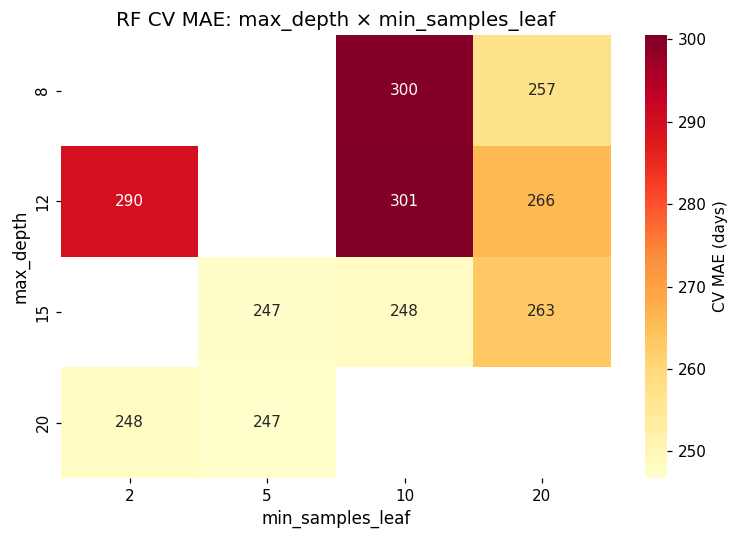

Saved 05_rf_depth_leaf_heatmap.png


In [ ]:
# Heatmap: max_depth × min_samples_leaf (averaged over other params)
tmp_heat = rf_cv[["param_max_depth", "param_min_samples_leaf", "cv_mae"]].copy()
tmp_heat["param_max_depth"]        = tmp_heat["param_max_depth"].astype(str)
tmp_heat["param_min_samples_leaf"] = tmp_heat["param_min_samples_leaf"].astype(str)

pivot_rf = tmp_heat.pivot_table(
    index="param_max_depth",
    columns="param_min_samples_leaf",
    values="cv_mae",
    aggfunc="mean",
)

if len(pivot_rf) >= 2 and len(pivot_rf.columns) >= 2:
    pivot_rf = pivot_rf.loc[
        _sort_str_labels(pivot_rf.index.tolist()),
        _sort_str_labels(pivot_rf.columns.tolist()),
    ]
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(pivot_rf, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "CV MAE (days)"})
    ax.set_title("RF CV MAE: max_depth × min_samples_leaf", fontsize=13)
    ax.set_xlabel("min_samples_leaf", fontsize=11)
    ax.set_ylabel("max_depth", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGS_DIR / "05_rf_depth_leaf_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved 05_rf_depth_leaf_heatmap.png")
else:
    print("Not enough combinations for a heatmap — increase N_ITER.")

### 2.3 Best Configuration

In [ ]:
rf_best_params = rf_search.best_params_
print("Best RF parameters (by CV MAE on search sample):")
for k, v in rf_best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest CV MAE: {-rf_search.best_score_:.1f} days")

Best RF parameters (by CV MAE on search sample):
  n_estimators: 300
  min_samples_leaf: 5
  max_features: 0.4
  max_depth: 20

Best CV MAE: 246.3 days


## 3. XGBoost Hyperparameter Search

### 3.1 Randomized Search (CV)

In [ ]:
import xgboost as xgb

xgb_param_dist = {
    "n_estimators":   [200, 300, 500, 800],
    "max_depth":      [4, 6, 8, 10],
    "learning_rate":  [0.01, 0.03, 0.05, 0.1, 0.15],
    "subsample":      [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_alpha":      [0.0, 0.1, 0.5],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    ),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_SEED,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

print("Running RandomizedSearchCV for XGBoost ...")
t0 = time.time()
xgb_search.fit(X_sample, y_sample)
print(f"Done in {time.time() - t0:.1f}s")

xgb_cv = pd.DataFrame(xgb_search.cv_results_)
xgb_cv["cv_mae"]     = -xgb_cv["mean_test_score"]
xgb_cv["cv_mae_std"] = xgb_cv["std_test_score"]
xgb_cv = xgb_cv.sort_values("cv_mae").reset_index(drop=True)

xgb_display = [
    "param_n_estimators", "param_max_depth", "param_learning_rate",
    "param_subsample", "param_min_child_weight", "cv_mae", "cv_mae_std"
]
print("\nTop 10 XGBoost configurations (by CV MAE):")
xgb_cv[xgb_display].head(10).style.format({"cv_mae": "{:.1f}", "cv_mae_std": "{:.1f}"})

Running RandomizedSearchCV for XGBoost ...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Done in 96.7s

Top 10 XGBoost configurations (by CV MAE):


,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_min_child_weight,cv_mae,cv_mae_std
0,800,8,0.010000,0.800000,1,244.7,2.1
1,800,6,0.030000,0.600000,10,245.6,2.4
2,500,10,0.010000,0.800000,1,245.6,2.3
3,200,10,0.050000,0.800000,5,245.7,2.7
4,200,10,0.050000,0.700000,10,245.8,2.7
5,500,10,0.030000,0.800000,10,246.4,2.7
6,800,4,0.050000,0.800000,10,246.5,2.9
7,800,4,0.050000,0.800000,5,246.7,3.2
8,200,6,0.030000,0.700000,5,248.4,2.1
9,300,8,0.100000,1.000000,10,249.1,2.5


### 3.2 Visualizations

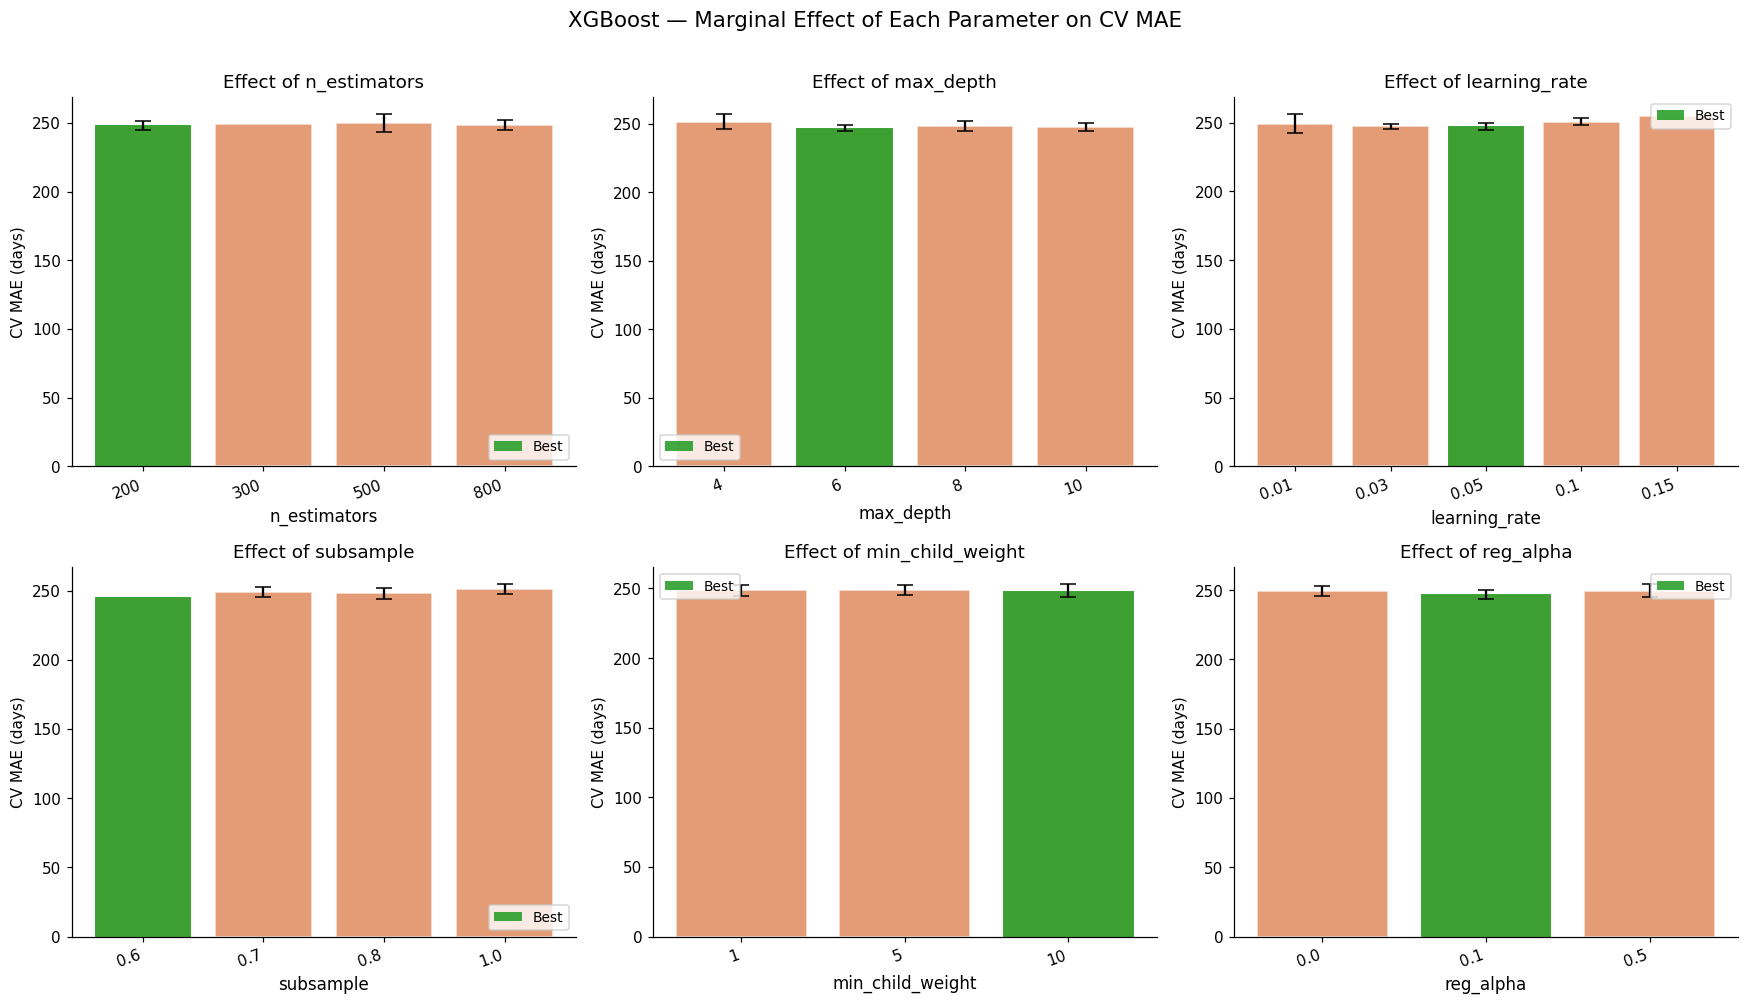

Saved 05_xgb_param_sensitivity.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("XGBoost — Marginal Effect of Each Parameter on CV MAE", fontsize=14, y=1.01)

xgb_param_cols = [
    ("param_n_estimators",     "n_estimators"),
    ("param_max_depth",        "max_depth"),
    ("param_learning_rate",    "learning_rate"),
    ("param_subsample",        "subsample"),
    ("param_min_child_weight", "min_child_weight"),
    ("param_reg_alpha",        "reg_alpha"),
]

for ax, (col, label) in zip(axes.flat, xgb_param_cols):
    grouped = _param_grouped(xgb_cv, col)
    x_pos = np.arange(len(grouped))

    ax.bar(x_pos, grouped["mean"], yerr=grouped["std"],
           capsize=5, color="#DD8452", alpha=0.8, edgecolor="white")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(grouped[col].tolist(), rotation=20, ha="right")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("CV MAE (days)", fontsize=10)
    ax.set_title(f"Effect of {label}")

    best_idx = grouped["mean"].idxmin()
    ax.bar(x_pos[best_idx], grouped["mean"].iloc[best_idx],
           color="#2ca02c", alpha=0.9, label="Best")
    ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGS_DIR / "05_xgb_param_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_xgb_param_sensitivity.png")

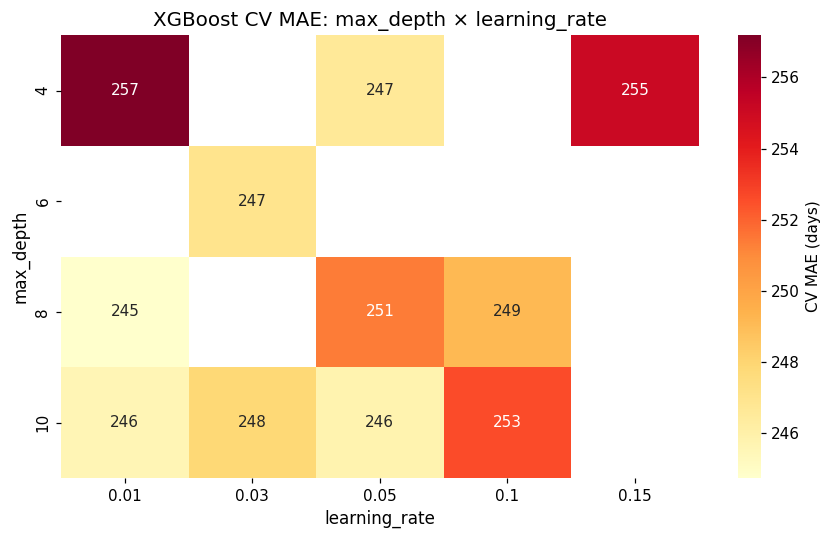

Saved 05_xgb_depth_lr_heatmap.png


In [ ]:
# Heatmap: max_depth × learning_rate
tmp_heat2 = xgb_cv[["param_max_depth", "param_learning_rate", "cv_mae"]].copy()
tmp_heat2["param_max_depth"]     = tmp_heat2["param_max_depth"].astype(str)
tmp_heat2["param_learning_rate"] = tmp_heat2["param_learning_rate"].astype(str)

pivot_xgb = tmp_heat2.pivot_table(
    index="param_max_depth",
    columns="param_learning_rate",
    values="cv_mae",
    aggfunc="mean",
)

if len(pivot_xgb) >= 2 and len(pivot_xgb.columns) >= 2:
    pivot_xgb = pivot_xgb.loc[
        _sort_str_labels(pivot_xgb.index.tolist()),
        _sort_str_labels(pivot_xgb.columns.tolist()),
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot_xgb, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "CV MAE (days)"})
    ax.set_title("XGBoost CV MAE: max_depth × learning_rate", fontsize=13)
    ax.set_xlabel("learning_rate", fontsize=11)
    ax.set_ylabel("max_depth", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGS_DIR / "05_xgb_depth_lr_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved 05_xgb_depth_lr_heatmap.png")
else:
    print("Not enough combinations for a heatmap — increase N_ITER.")

### 3.3 Best Configuration

In [ ]:
xgb_best_params = xgb_search.best_params_
print("Best XGBoost parameters (by CV MAE on search sample):")
for k, v in xgb_best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest CV MAE: {-xgb_search.best_score_:.1f} days")

Best XGBoost parameters (by CV MAE on search sample):
  subsample: 0.8
  reg_alpha: 0.1
  n_estimators: 800
  min_child_weight: 1
  max_depth: 8
  learning_rate: 0.01

Best CV MAE: 244.7 days


## 4. Neural Network Hyperparameter Search

PyTorch doesn't plug into `RandomizedSearchCV`, so we run a manual grid of **8 configurations**
for 20 epochs each (early stopping patience = 5), tracking validation RMSE.

### 4.1 Load NN Data

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from src.preprocessing_neural_net import prepare_for_neural_net

# ── Device ────────────────────────────────────────────────────────────────────
# CPU is faster than MPS for this small MLP — MPS kernel-launch overhead
# outweighs compute for batch_size=1024 with <300 parameters per layer.
# Switch to "mps" below only if you want to experiment.
device = torch.device("cpu")
print(f"Device: {device}")

# ── Temporal 70/15/15 split ───────────────────────────────────────────────────
df_valid  = df[df["los_days"].notna() & (df["los_days"] >= 0)].copy()
dates_nn  = pd.to_datetime(df_valid["case_open_date"])
p70       = dates_nn.quantile(0.70)
p85       = dates_nn.quantile(0.85)
idx_train = np.where((dates_nn < p70).values)[0]           # type: ignore
idx_val   = np.where(((dates_nn >= p70) & (dates_nn < p85)).values)[0]  # type: ignore
idx_test  = np.where((dates_nn >= p85).values)[0]           # type: ignore
print(f"Temporal split — train: up to {str(p70)[:10]}  "
      f"val: {str(p70)[:10]}–{str(p85)[:10]}  test: after {str(p85)[:10]}")
print(f"  train={len(idx_train):,}  val={len(idx_val):,}  test={len(idx_test):,}")

# ── Tensor cache ──────────────────────────────────────────────────────────────
_CACHE = ROOT / "data" / "aggregations" / "_nn_tensors_cache.pt"

if _CACHE.exists():
    print(f"Loading cached tensors from {_CACHE.name} …")
    _c            = torch.load(_CACHE, weights_only=True)
    numeric_t     = _c["numeric_t"]
    judges_t      = _c["judges_t"]
    target_t      = _c["target_t"]
    n_numeric     = int(_c["n_numeric"])
    judge_vocab_size = int(_c["judge_vocab_size"])
else:
    print("Building tensors (first run — will be cached for next time) …")
    _t0 = time.time()
    prepared_data, y_nn = prepare_for_neural_net(df_valid)
    n_numeric        = prepared_data["numeric_features"].shape[1]
    judge_vocab_size = prepared_data["judges_vocab_size"]
    numeric_t = torch.tensor(prepared_data["numeric_features"], dtype=torch.float32)
    judges_t  = torch.tensor(prepared_data["judges_encoded"],   dtype=torch.long)
    target_t  = torch.tensor(y_nn.values,                       dtype=torch.float32)
    torch.save({
        "numeric_t": numeric_t, "judges_t": judges_t, "target_t": target_t,
        "n_numeric": n_numeric, "judge_vocab_size": judge_vocab_size,
    }, _CACHE)
    print(f"Done in {time.time()-_t0:.1f}s — cached to {_CACHE.name}")

# ── Pre-move tensors to device once ──────────────────────────────────────────
# Moving all 168K rows to device here means DataLoader yields device-tensors
# directly — zero per-batch CPU↔device transfers during training.
numeric_t = numeric_t.to(device)
judges_t  = judges_t.to(device)
target_t  = target_t.to(device)
print(f"Numeric features: {n_numeric}  |  Judge vocab: {judge_vocab_size}")

### 4.2 Model & Training Helpers

In [ ]:
class _Head(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


class CourtNN(nn.Module):
    def __init__(self, n_numeric, judge_vocab_size, emb_dim=16, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.judge_emb = nn.Embedding(judge_vocab_size, emb_dim, padding_idx=0)
        self.head      = _Head(n_numeric + emb_dim, hidden_dim, dropout)
    def forward(self, num, jid):
        return self.head(torch.cat([num, self.judge_emb(jid)], dim=1))


def make_loaders(idx_tr, idx_va, idx_te, batch_size):
    # Tensors are already on device (moved once in the data cell).
    def ds(idx): return TensorDataset(numeric_t[idx], judges_t[idx], target_t[idx])
    return (
        DataLoader(ds(idx_tr), batch_size=batch_size, shuffle=True,  num_workers=0),
        DataLoader(ds(idx_va), batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(ds(idx_te), batch_size=batch_size, shuffle=False, num_workers=0),
    )


def train_one_epoch(model, loader, opt, crit, dev):
    model.train()
    total = torch.zeros(1, device=dev)
    for num, jid, tgt in loader:               # already on device — no .to(dev)
        opt.zero_grad()
        loss = crit(model(num, jid), tgt)
        loss.backward()
        opt.step()
        total += loss.detach() * len(tgt)
    return (total / len(loader.dataset)).item()  # single sync per epoch


@torch.no_grad()
def eval_loader(model, loader, crit, dev):
    model.eval()
    total   = torch.zeros(1, device=dev)
    preds   = []
    targets = []
    for num, jid, tgt in loader:               # already on device — no .to(dev)
        p = model(num, jid)
        total += crit(p, tgt).detach() * len(tgt)
        preds.append(p)
        targets.append(tgt)
    # Single CPU transfer at end of pass — not once per batch.
    return (
        (total / len(loader.dataset)).item(),
        torch.cat(preds).cpu().numpy(),
        torch.cat(targets).cpu().numpy(),
    )


def run_nn_config(cfg, max_epochs=20, patience=5, train_idx=None):
    if train_idx is None:
        train_idx = idx_train

    model = CourtNN(
        n_numeric=n_numeric,
        judge_vocab_size=judge_vocab_size,
        emb_dim=cfg["emb_dim"],
        hidden_dim=cfg["hidden_dim"],
        dropout=cfg["dropout"],
    ).to(device)

    crit  = nn.MSELoss()
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    train_loader, val_loader, test_loader = make_loaders(
        train_idx, idx_val, idx_test, batch_size=cfg["batch_size"]
    )

    train_rmses, val_rmses = [], []
    best_val, best_state, no_imp = float("inf"), None, 0
    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        tr = train_one_epoch(model, train_loader, opt, crit, device)
        va, _, _ = eval_loader(model, val_loader, crit, device)
        sched.step(va)
        train_rmses.append(tr ** 0.5)
        val_rmses.append(va ** 0.5)

        if va < best_val - 1.0:
            best_val  = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp    = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            break

    if best_state:
        model.load_state_dict(best_state)

    _, y_pred, y_true = eval_loader(model, test_loader, crit, device)
    return {
        "mae":           mean_absolute_error(y_true, y_pred),
        "rmse":          mean_squared_error(y_true, y_pred) ** 0.5,
        "r2":            r2_score(y_true, y_pred),
        "best_val_rmse": best_val ** 0.5,
        "epochs_run":    len(train_rmses),
        "train_time":    round(time.time() - t0, 1),
        "train_rmses":   train_rmses,
        "val_rmses":     val_rmses,
    }

print("Helpers defined.")

### 4.3 Config Grid & Training Loop

In [ ]:
nn_configs = [
    {"name": "small",         "hidden_dim":  64, "emb_dim": 16, "dropout": 0.2, "lr": 1e-3, "batch_size": 1024},
    {"name": "baseline",      "hidden_dim": 128, "emb_dim": 16, "dropout": 0.3, "lr": 1e-3, "batch_size": 1024},
    {"name": "large",         "hidden_dim": 256, "emb_dim": 16, "dropout": 0.3, "lr": 1e-3, "batch_size": 1024},
    {"name": "hi_dropout",    "hidden_dim": 128, "emb_dim": 16, "dropout": 0.5, "lr": 1e-3, "batch_size": 1024},
    {"name": "lo_lr",         "hidden_dim": 128, "emb_dim": 16, "dropout": 0.3, "lr": 5e-4, "batch_size": 1024},
    {"name": "hi_lr",         "hidden_dim": 128, "emb_dim": 16, "dropout": 0.3, "lr": 5e-3, "batch_size": 1024},
    {"name": "big_batch",     "hidden_dim": 128, "emb_dim": 16, "dropout": 0.3, "lr": 1e-3, "batch_size": 2048},
    {"name": "large_emb",     "hidden_dim": 128, "emb_dim": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 1024},
]

# Subsample training indices for the search — same budget as RF/XGBoost (25k rows).
# val/test always use the full split so metrics are comparable across configs.
rng_nn = np.random.default_rng(RANDOM_SEED)
idx_train_sample = rng_nn.choice(idx_train, size=min(SEARCH_SAMPLE, len(idx_train)), replace=False)
print(f"NN search sample: {len(idx_train_sample):,} / {len(idx_train):,} training cases")

nn_results = []
for i, cfg in enumerate(nn_configs):
    print(f"[{i+1}/{len(nn_configs)}] {cfg['name']:20s} ", end="", flush=True)
    res = run_nn_config(cfg, max_epochs=20, patience=5, train_idx=idx_train_sample)
    nn_results.append({**cfg, **res})
    print(f"MAE={res['mae']:.1f}  RMSE={res['rmse']:.1f}  R²={res['r2']:.4f}  "
          f"({res['epochs_run']} ep, {res['train_time']}s)")

nn_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("train_rmses", "val_rmses")}
    for r in nn_results
]).sort_values("mae")

print("\nNN configs sorted by test MAE:")
nn_df[["name","hidden_dim","emb_dim","dropout","lr","batch_size",
       "mae","rmse","r2","best_val_rmse","epochs_run","train_time"]]\
  .style.format({"mae":"{:.1f}","rmse":"{:.1f}","r2":"{:.4f}",
                 "best_val_rmse":"{:.1f}","train_time":"{:.1f}"})

### 4.4 Visualizations

In [ ]:
# Bar chart: test MAE per NN config
nn_sorted = nn_df.sort_values("mae")
colors = ["#2ca02c" if n == nn_sorted.iloc[0]["name"] else "#9467bd"
          for n in nn_sorted["name"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Neural Network — Config Comparison", fontsize=14)

for ax, metric, ylabel in zip(
    axes,
    ["mae", "rmse", "r2"],
    ["Test MAE (days)", "Test RMSE (days)", "Test R²"],
):
    vals = nn_sorted[metric]
    bars = ax.barh(nn_sorted["name"][::-1], vals[::-1],
                   color=colors[::-1], edgecolor="white", alpha=0.85)
    ax.set_xlabel(ylabel, fontsize=11)
    ax.set_title(ylabel)
    for bar, v in zip(bars, vals[::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}" if metric != "r2" else f"{v:.4f}",
                va="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIGS_DIR / "05_nn_config_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_nn_config_comparison.png")

In [ ]:
# Loss curves for the top 3 NN configs (by test MAE)
top3_names = nn_df["name"].head(3).tolist()
top3_results = [r for r in nn_results if r["name"] in top3_names]

fig, axes = plt.subplots(1, len(top3_results), figsize=(14, 4), sharey=True)
if len(top3_results) == 1:
    axes = [axes]

for ax, res in zip(axes, top3_results):
    ep = range(1, len(res["train_rmses"]) + 1)
    ax.plot(ep, res["train_rmses"], label="Train RMSE", color="#1f77b4")
    ax.plot(ep, res["val_rmses"],   label="Val RMSE",   color="#ff7f0e")
    ax.set_title(f"{res['name']}\nMAE={res['mae']:.1f}  R²={res['r2']:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE (days)")
    ax.legend(fontsize=9)

fig.suptitle("Loss Curves — Top 3 NN Configurations", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGS_DIR / "05_nn_top3_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_nn_top3_loss_curves.png")

In [ ]:
# Sensitivity: show how individual NN params affect test MAE
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("NN — Single-Parameter Effect on Test MAE (others held at baseline)", fontsize=12)

nn_param_cols = [
    ("hidden_dim", "hidden_dim"),
    ("dropout",    "dropout"),
    ("lr",         "learning_rate"),
    ("batch_size", "batch_size"),
]

for ax, (col, label) in zip(axes, nn_param_cols):
    grouped = nn_df.groupby(col)["mae"].agg(["mean", "std"]).reset_index()
    grouped = grouped.sort_values(col)
    x_pos = np.arange(len(grouped))
    ax.bar(x_pos, grouped["mean"], yerr=grouped["std"],
           capsize=5, color="#9467bd", alpha=0.8, edgecolor="white")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in grouped[col]], rotation=20, ha="right")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Test MAE (days)", fontsize=10)
    ax.set_title(f"Effect of {label}")
    best_i = grouped["mean"].idxmin()
    ax.bar(x_pos[best_i], grouped["mean"].iloc[best_i], color="#2ca02c", alpha=0.9)

fig.tight_layout()
fig.savefig(FIGS_DIR / "05_nn_param_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_nn_param_sensitivity.png")

## 5. Final Comparison — Retrain Best Models on Full Data

In [ ]:
# ─── Retrain RF with best params ───────────────────────────────────────────────
print("Retraining RF with best params on full training set ...")
t0 = time.time()
rf_final = RandomForestRegressor(
    **rf_best_params, random_state=RANDOM_SEED, n_jobs=-1
)
rf_final.fit(X_train_full, y_train_full)
y_pred_rf = rf_final.predict(X_test)
rf_final_metrics = {
    "MAE":  round(mean_absolute_error(y_test, y_pred_rf), 2),
    "RMSE": round(mean_squared_error(y_test, y_pred_rf) ** 0.5, 2),
    "R2":   round(r2_score(y_test, y_pred_rf), 4),
}
print(f"  RF final  →  MAE={rf_final_metrics['MAE']}  RMSE={rf_final_metrics['RMSE']}  R²={rf_final_metrics['R2']}  ({time.time()-t0:.1f}s)")

# ─── Retrain XGBoost with best params ──────────────────────────────────────────
print("Retraining XGBoost with best params on full training set ...")
t0 = time.time()
xgb_final = xgb.XGBRegressor(
    **xgb_best_params,
    colsample_bytree=0.8, reg_lambda=1.0,
    random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
)
xgb_final.fit(X_train_full, y_train_full)
y_pred_xgb = xgb_final.predict(X_test)
xgb_final_metrics = {
    "MAE":  round(mean_absolute_error(y_test, y_pred_xgb), 2),
    "RMSE": round(mean_squared_error(y_test, y_pred_xgb) ** 0.5, 2),
    "R2":   round(r2_score(y_test, y_pred_xgb), 4),
}
print(f"  XGB final →  MAE={xgb_final_metrics['MAE']}  RMSE={xgb_final_metrics['RMSE']}  R²={xgb_final_metrics['R2']}  ({time.time()-t0:.1f}s)")

In [ ]:
# ─── Retrain best NN config on full data ───────────────────────────────────────
best_nn_cfg = nn_df.iloc[0].to_dict()
print(f"Best NN config: {best_nn_cfg['name']}")
print(f"  hidden_dim={int(best_nn_cfg['hidden_dim'])}  emb_dim={int(best_nn_cfg['emb_dim'])}  "
      f"dropout={best_nn_cfg['dropout']}  lr={best_nn_cfg['lr']}  batch_size={int(best_nn_cfg['batch_size'])}")

nn_best_res = run_nn_config(
    {
        "hidden_dim":  int(best_nn_cfg["hidden_dim"]),
        "emb_dim":     int(best_nn_cfg["emb_dim"]),
        "dropout":     float(best_nn_cfg["dropout"]),
        "lr":          float(best_nn_cfg["lr"]),
        "batch_size":  int(best_nn_cfg["batch_size"]),
    },
    max_epochs=40,   # full epochs for final model
    patience=8,
)
nn_final_metrics = {
    "MAE":  round(nn_best_res["mae"],  2),
    "RMSE": round(nn_best_res["rmse"], 2),
    "R2":   round(nn_best_res["r2"],   4),
}
print(f"  NN final  →  MAE={nn_final_metrics['MAE']}  RMSE={nn_final_metrics['RMSE']}  R²={nn_final_metrics['R2']}")

In [ ]:
# ─── Cross-model comparison bar chart ─────────────────────────────────────────
# Also add the original "default" results for reference
original_results = {
    "RF (default)": {"MAE": 239.49, "RMSE": 472.68, "R2": 0.4709},
    "XGB (default)": {"MAE": 233.97, "RMSE": 466.55, "R2": 0.4845},
    "NN (default)":  {"MAE": 235.70, "RMSE": 469.23, "R2": 0.4688},
}

tuned_results = {
    "RF (tuned)": rf_final_metrics,
    "XGB (tuned)": xgb_final_metrics,
    "NN (tuned)": nn_final_metrics,
}

all_models = {**original_results, **tuned_results}
comparison_df = pd.DataFrame(all_models).T.reset_index().rename(columns={"index": "Model"})
print("\nFull comparison:")
display(comparison_df.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.4f}"}))

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison: Default vs Tuned Hyperparameters", fontsize=14)

metric_cfg = [
    ("MAE",  "Test MAE (days)",  "lower is better"),
    ("RMSE", "Test RMSE (days)", "lower is better"),
    ("R2",   "Test R²",          "higher is better"),
]

default_names = list(original_results.keys())
tuned_names   = list(tuned_results.keys())
palette_def   = ["#aec7e8", "#ffbb78", "#c5b0d5"]
palette_tuned = ["#1f77b4", "#ff7f0e", "#9467bd"]

for ax, (metric, ylabel, note) in zip(axes, metric_cfg):
    x = np.arange(3)
    w = 0.38
    def_vals   = [original_results[m][metric] for m in default_names]
    tuned_vals = [tuned_results[m][metric]    for m in tuned_names]
    model_names = ["RF", "XGBoost", "NN"]

    bars_d = ax.bar(x - w/2, def_vals,   w, label="Default",
                    color=palette_def,   alpha=0.8, edgecolor="white")
    bars_t = ax.bar(x + w/2, tuned_vals, w, label="Tuned",
                    color=palette_tuned, alpha=0.9, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"{ylabel}\n({note})", fontsize=11)
    ax.legend(fontsize=9)

    for bar, v in zip(list(bars_d) + list(bars_t), def_vals + tuned_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.002 if metric == "R2" else 2),
            f"{v:.1f}" if metric != "R2" else f"{v:.4f}",
            ha="center", va="bottom", fontsize=7.5,
        )

fig.tight_layout()
fig.savefig(FIGS_DIR / "05_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved 05_model_comparison.png")

### 5.3 Save Results to JSON

In [ ]:
output = {
    "search_config": {
        "search_sample": SEARCH_SAMPLE,
        "cv_folds": CV_FOLDS,
        "n_iter": N_ITER,
        "random_seed": RANDOM_SEED,
    },
    "RandomForest": {
        "best_params": rf_best_params,
        "best_cv_mae_sample": round(-rf_search.best_score_, 2),
        "final_metrics_full_data": rf_final_metrics,
    },
    "XGBoost": {
        "best_params": xgb_best_params,
        "best_cv_mae_sample": round(-xgb_search.best_score_, 2),
        "final_metrics_full_data": xgb_final_metrics,
    },
    "NeuralNet": {
        "best_config_name": str(best_nn_cfg["name"]),
        "best_params": {
            "hidden_dim":  int(best_nn_cfg["hidden_dim"]),
            "emb_dim":     int(best_nn_cfg["emb_dim"]),
            "dropout":     float(best_nn_cfg["dropout"]),
            "lr":          float(best_nn_cfg["lr"]),
            "batch_size":  int(best_nn_cfg["batch_size"]),
        },
        "search_configs": [
            {
                "name":       r["name"],
                "hidden_dim": int(r["hidden_dim"]),
                "emb_dim":    int(r["emb_dim"]),
                "dropout":    float(r["dropout"]),
                "lr":         float(r["lr"]),
                "batch_size": int(r["batch_size"]),
                "test_mae":   round(r["mae"], 2),
                "test_rmse":  round(r["rmse"], 2),
                "test_r2":    round(r["r2"], 4),
                "best_val_rmse": round(r["best_val_rmse"], 2),
                "epochs_run": int(r["epochs_run"]),
            }
            for r in nn_results
        ],
        "final_metrics_full_epochs": nn_final_metrics,
    },
    "original_baseline_metrics": original_results,
}

out_path = DOCS_DIR / "05_hyperparameter_results.json"
out_path.write_text(json.dumps(output, indent=2))
print(f"Saved {out_path.relative_to(ROOT)}")

## 6. Summary

| Model | Metric | Default | Tuned | Δ |
|-------|--------|---------|-------|---|
| RF    | MAE    | 239.5   | (see above) | — |
| XGB   | MAE    | 234.0   | (see above) | — |
| NN    | MAE    | 235.7   | (see above) | — |

**Figures produced:**
- `05_rf_param_sensitivity.png` — RF: marginal effect per parameter
- `05_rf_depth_leaf_heatmap.png` — RF: 2-way interaction heatmap
- `05_xgb_param_sensitivity.png` — XGB: marginal effect per parameter
- `05_xgb_depth_lr_heatmap.png` — XGB: depth × learning_rate heatmap
- `05_nn_config_comparison.png` — NN: all 8 configs by MAE / RMSE / R²
- `05_nn_top3_loss_curves.png` — NN: train/val RMSE curves for top 3 configs
- `05_nn_param_sensitivity.png` — NN: individual parameter effects
- `05_model_comparison.png` — side-by-side default vs tuned across all three models